# Bike Sharing Demand Prediction

## Business Objective

BoomBikes wants to understand which factors affect the demand for shared bikes.

The objective of this project is to build a Multiple Linear Regression model that predicts bike demand using available independent variables.

In [55]:
import pandas as pd

bike = pd.read_csv("Bike Sharing dataset.csv")

bike.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [56]:
bike.shape

(730, 16)

In [57]:
bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


In [58]:
bike.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [59]:
bike.duplicated().sum()

np.int64(0)

## Data Understanding

In [60]:
bike.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

### Target Variable

The target variable for this analysis is 'cnt', which represents the total number of bike rentals in a day.

In [61]:
bike.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.997260,0.683562,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.006161,0.465405,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


## Data Cleaning

In [62]:
bike.drop(['instant','dteday'], axis=1, inplace=True)

bike.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [63]:
bike.shape

(730, 14)

## Correlation Analysis

In [64]:
bike.corr(numeric_only=True)

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
season,1.000000e+00,-3.279074e-16,8.310321e-01,-0.010868,-0.003081,0.013762,0.021306,0.333361,0.342014,0.208220,-0.229607,0.208737,0.410310,0.404584
yr,-3.279074e-16,1.000000e+00,-5.162656e-16,0.008195,-0.005466,-0.002945,-0.050322,0.048789,0.047215,-0.112547,-0.011624,0.250502,0.596911,0.569728
mnth,8.310321e-01,-5.162656e-16,1.000000e+00,0.018905,0.009523,-0.004688,0.045613,0.219083,0.226430,0.224937,-0.208013,0.121208,0.291952,0.278191
holiday,-1.086804e-02,8.195345e-03,1.890483e-02,1.000000,-0.101962,-0.252948,-0.034395,-0.028764,-0.032703,-0.015662,0.006257,0.054055,-0.109142,-0.068764
weekday,-3.081198e-03,-5.466369e-03,9.522969e-03,-0.101962,1.000000,0.035800,0.031112,-0.000168,-0.007539,-0.052290,0.014283,0.059978,0.057427,0.067534
workingday,1.376178e-02,-2.945396e-03,-4.687953e-03,-0.252948,0.035800,1.000000,0.060236,0.053470,0.052940,0.023202,-0.018666,-0.517607,0.305437,0.062542
weathersit,2.130636e-02,-5.032247e-02,4.561335e-02,-0.034395,0.031112,0.060236,1.000000,-0.119503,-0.120559,0.590277,0.039769,-0.246044,-0.259025,-0.295929
temp,3.333607e-01,4.878919e-02,2.190833e-01,-0.028764,-0.000168,0.053470,-0.119503,1.000000,0.991696,0.128565,-0.158186,0.542731,0.539436,0.627044
atemp,3.420139e-01,4.721519e-02,2.264302e-01,-0.032703,-0.007539,0.052940,-0.120559,0.991696,1.000000,0.141512,-0.183876,0.543362,0.543678,0.630685
hum,2.082196e-01,-1.125471e-01,2.249368e-01,-0.015662,-0.052290,0.023202,0.590277,0.128565,0.141512,1.000000,-0.248506,-0.075211,-0.089212,-0.098543


### Initial Correlation Observations

- The target variable (cnt) has a strong positive correlation with temperature (temp and atemp).
- The target variable (cnt) has a strong positive correlation with registered users.
- The target variable (cnt) has a moderate positive correlation with year (yr).
- The target variable (cnt) has a negative correlation with weather situation (weathersit) and windspeed.
- Registered and casual users are highly correlated with cnt because cnt is the sum of these variables.

## Converting Categorical Variables

In [65]:
bike['season'] = bike['season'].map({
    1:'spring',
    2:'summer',
    3:'fall',
    4:'winter'
})

bike['weathersit'] = bike['weathersit'].map({
    1:'clear',
    2:'mist',
    3:'light_rain'
})

bike.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,spring,0,1,0,6,0,mist,14.110847,18.18125,80.5833,10.749882,331,654,985
1,spring,0,1,0,0,0,mist,14.902598,17.68695,69.6087,16.652113,131,670,801
2,spring,0,1,0,1,1,clear,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,spring,0,1,0,2,1,clear,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,spring,0,1,0,3,1,clear,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

## Univariate Analysis

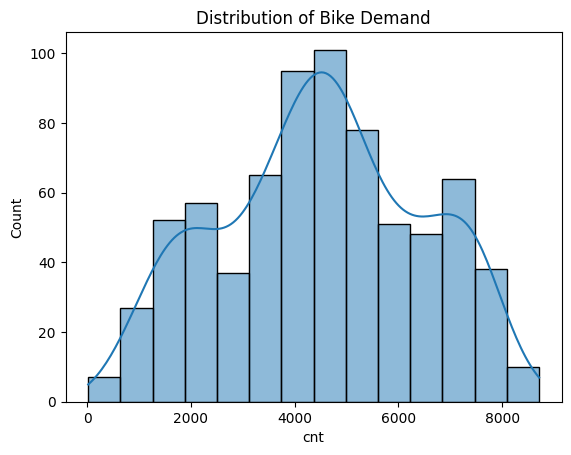

In [67]:
sns.histplot(bike['cnt'], kde=True)

plt.title('Distribution of Bike Demand')
plt.show()

### Observation

- The bike demand appears to be reasonably distributed around the middle range.
- Most rental counts lie between 3,000 and 6,000.
- Extremely low and extremely high rental counts are less frequent.

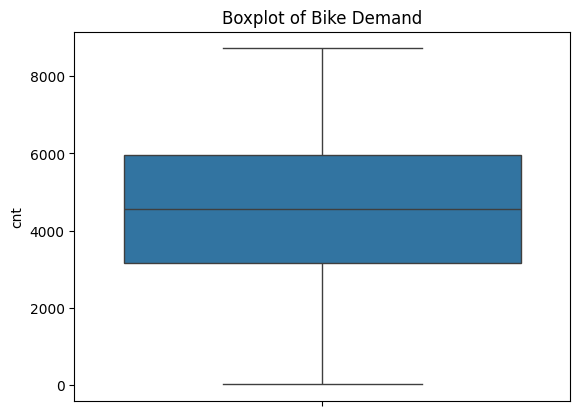

In [68]:
sns.boxplot(y=bike['cnt'])

plt.title('Boxplot of Bike Demand')
plt.show()

### Observation

- The median bike demand is around 4,500 rentals per day.
- Bike demand varies significantly across different days.
- No major outliers are visible in the target variable (cnt).

## Bivariate Analysis

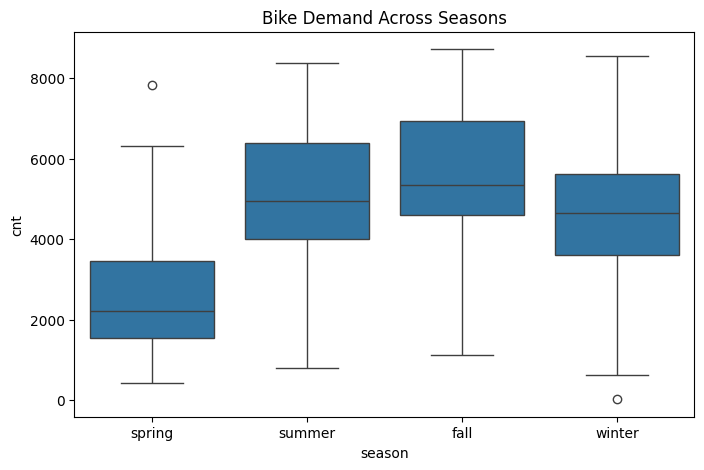

In [69]:
plt.figure(figsize=(8,5))

sns.boxplot(x='season', y='cnt', data=bike)

plt.title('Bike Demand Across Seasons')
plt.show()

### Observation: Bike Demand Across Seasons

* Bike demand varies considerably across seasons, indicating that seasonality plays an important role in influencing rentals.
* Fall shows the highest median bike demand (approximately 5,400 rentals/day), followed by summer (approximately 4,900 rentals/day).
* Spring records the lowest median demand (approximately 2,200 rentals/day), which is less than half of the median demand observed during fall.
* The interquartile range (IQR) is also relatively high for fall and summer, suggesting substantial variation in demand during these seasons.
* Overall, demand appears strongest during fall and summer and weakest during spring, making season a potentially important predictor in the regression model.

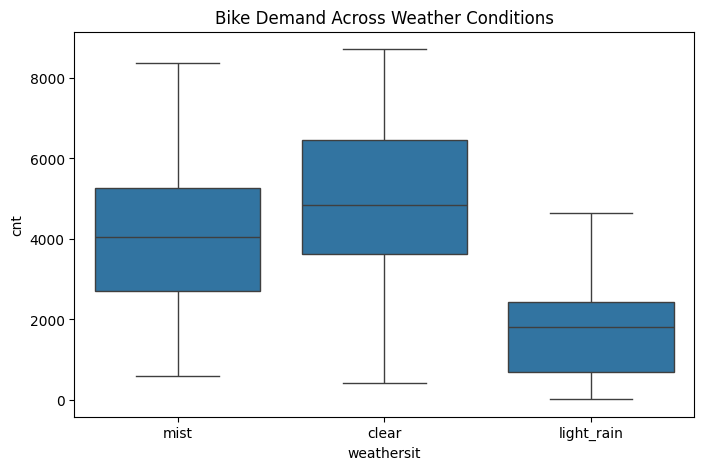

In [70]:
plt.figure(figsize=(8,5))

sns.boxplot(x='weathersit', y='cnt', data=bike)

plt.title('Bike Demand Across Weather Conditions')
plt.show()

### Observation: Bike Demand Across Weather Conditions

* Bike demand is highest during clear weather conditions, with a median demand close to 4,800 rentals/day.
* Demand under misty conditions is lower, with a median demand around 4,000 rentals/day.
* Light rain conditions show the lowest demand, with the median dropping below 2,000 rentals/day.
* The difference between clear weather and light rain is substantial, indicating that adverse weather conditions significantly reduce bike rentals.
* The boxplot suggests a strong relationship between weather conditions and bike demand, making weather a valuable predictor variable.

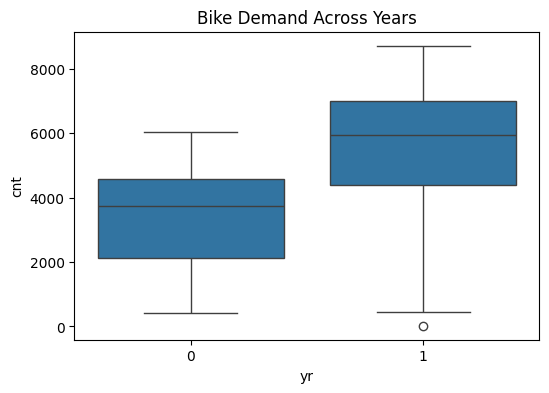

In [71]:
plt.figure(figsize=(6,4))

sns.boxplot(x='yr', y='cnt', data=bike)

plt.title('Bike Demand Across Years')
plt.show()

### Observation: Bike Demand Across Years

* Bike demand in 2019 (yr = 1) is noticeably higher than in 2018 (yr = 0).
* The median demand increased from approximately 3,800 rentals/day in 2018 to nearly 6,000 rentals/day in 2019.
* The upper range of demand is also significantly higher in 2019, with several days exceeding 8,000 rentals.
* This trend suggests increasing adoption and popularity of the bike-sharing service over time.
* The clear separation between the two distributions indicates that the variable 'yr' is likely to be an important contributor to the predictive model.


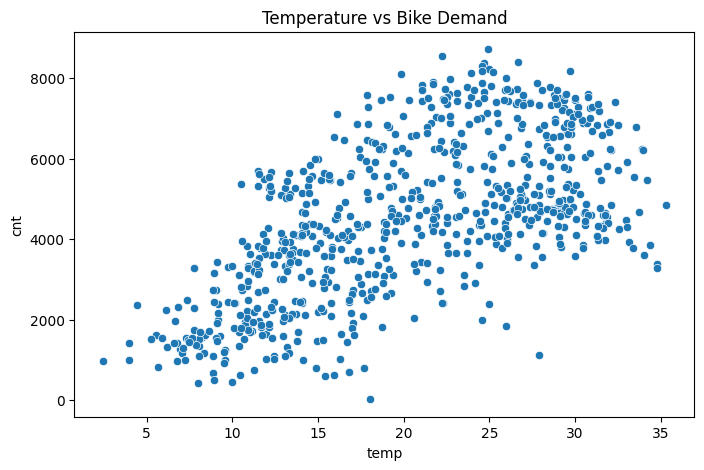

In [72]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='temp', y='cnt', data=bike)

plt.title('Temperature vs Bike Demand')
plt.show()

### Observation: Temperature vs Bike Demand

- A clear positive relationship is visible between temperature and bike demand.
- As temperature increases, the number of bike rentals generally increases.
- Lower temperatures (below approximately 10°C) are associated with relatively low rental counts, whereas higher temperatures frequently correspond to demand exceeding 6,000 rentals/day.
- The upward trend observed in the scatter plot supports the correlation analysis, where temperature showed a strong positive correlation with bike demand (correlation ≈ 0.63).
- Temperature appears to be one of the strongest numerical predictors of bike demand and should play a significant role in the final regression model.

## Additional Bivariate Analysis

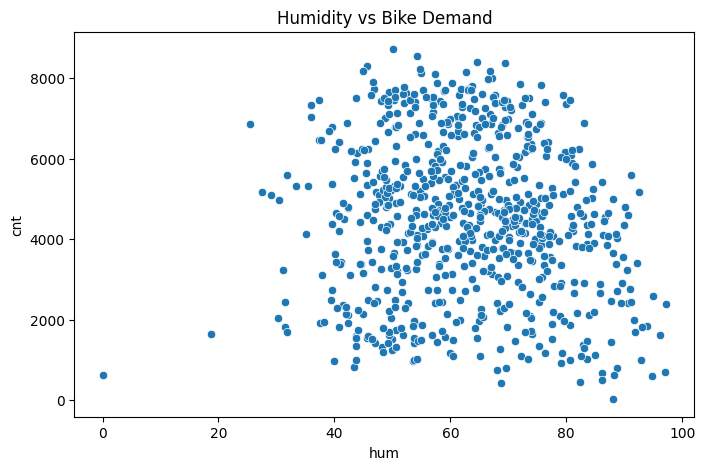

In [73]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='hum', y='cnt', data=bike)

plt.title('Humidity vs Bike Demand')
plt.show()

### Observation: Humidity vs Bike Demand

* The scatter plot indicates a weak negative relationship between humidity and bike demand.
* Higher rental counts are generally observed when humidity levels are between 40% and 70%.
* As humidity approaches 80%–100%, the number of high-demand days decreases noticeably.
* The correlation matrix also supports this observation, showing a weak negative correlation between humidity and bike demand (approximately -0.10).
* This suggests that extremely humid conditions may discourage bike rentals, although humidity appears to be a relatively weaker predictor compared to temperature.

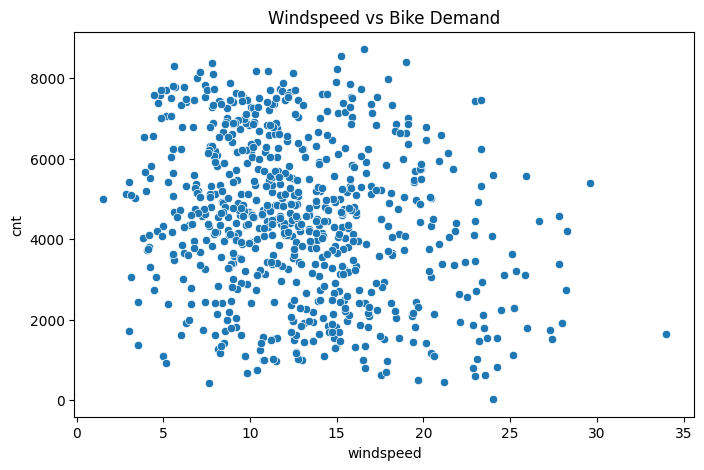

In [74]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='windspeed', y='cnt', data=bike)

plt.title('Windspeed vs Bike Demand')
plt.show()

### Observation: Windspeed vs Bike Demand

* The scatter plot shows a negative relationship between windspeed and bike demand.
* Higher rental counts are concentrated at lower windspeed values, typically below 15 units.
* As windspeed increases, the frequency of high-demand days decreases.
* The correlation heatmap shows a weak negative correlation between windspeed and bike demand (approximately -0.24).
* While windspeed does affect bike rentals, its impact appears less significant than temperature, season, or weather conditions.

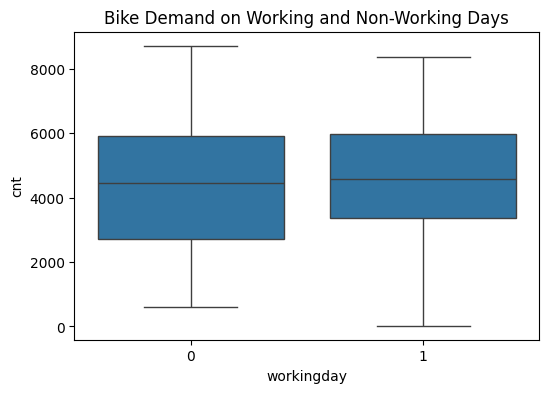

In [75]:
plt.figure(figsize=(6,4))

sns.boxplot(x='workingday', y='cnt', data=bike)

plt.title('Bike Demand on Working and Non-Working Days')
plt.show()

### Observation: Bike Demand on Working and Non-Working Days

* The median bike demand is slightly higher on working days compared to non-working days.
* The overall distribution of demand appears similar across both categories.
* The overlap between the two boxplots suggests that working day status alone may not strongly influence bike demand.
* This observation is consistent with the correlation matrix, where workingday shows a very weak correlation with bike demand (approximately 0.06).
* Therefore, workingday may contribute limited predictive power to the final regression model.

## Correlation Heatmap

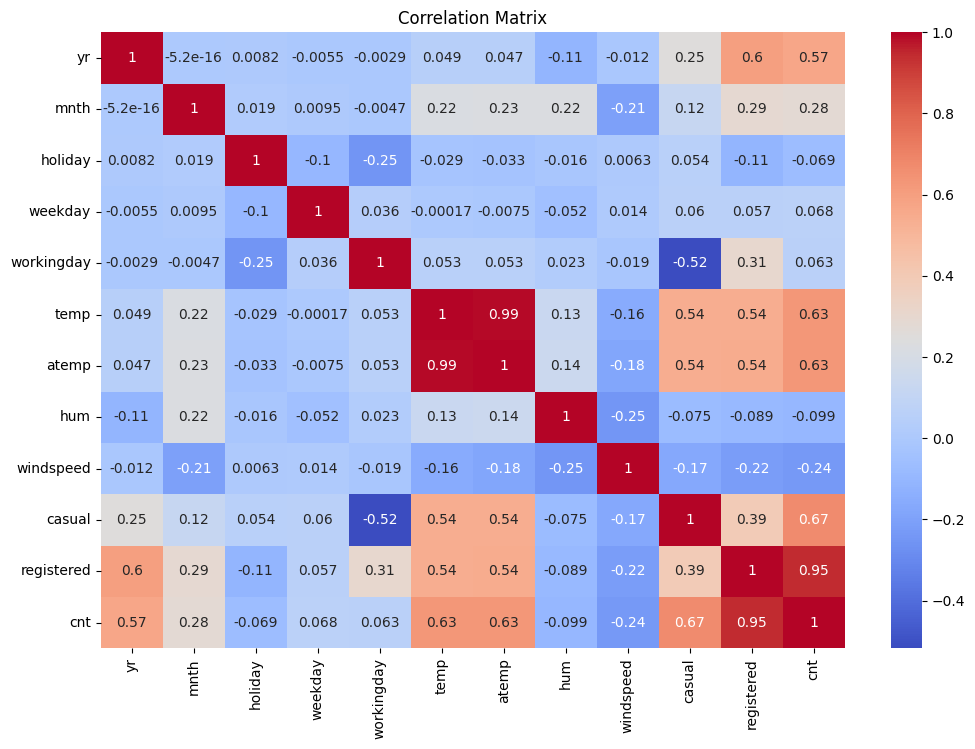

In [76]:
plt.figure(figsize=(12,8))

sns.heatmap(
    bike.select_dtypes(include=['number']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

### Observation: Correlation Heatmap

- Temperature (temp) and feeling temperature (atemp) show a very strong positive correlation with bike demand (approximately 0.63 each).
- Year (yr) exhibits a moderately strong positive correlation with bike demand (approximately 0.57), indicating increasing demand over time.
- Windspeed (-0.24) and humidity (-0.10) are negatively correlated with bike demand.
- Registered users show an extremely high correlation with bike demand (approximately 0.95), while casual users also show a strong positive correlation (approximately 0.67).
- Temperature (temp) and feeling temperature (atemp) are highly correlated with each other (approximately 0.99), suggesting potential multicollinearity.
- Since 'cnt' is derived using 'casual' and 'registered', these variables may introduce data leakage and should be carefully evaluated before model building.

# **Key EDA Findings**

## 1. Seasonal Impact on Bike Demand

**Key Highlights:** Seasonal Demand • Fall Peak • Spring Low

The analysis reveals a strong seasonal pattern in bike rentals. Bike demand is lowest during the spring season, with a median demand of approximately 2,200 rentals per day. In contrast, fall records the highest median demand, exceeding 5,400 rentals per day.

Summer and winter also demonstrate substantially higher demand compared to spring. The large variation in rental volumes across seasons indicates that seasonal changes significantly influence customer behavior and bike usage patterns.

From a business perspective, this suggests that demand forecasting, inventory planning, and resource allocation should account for seasonal fluctuations.

## 2. Weather Conditions Influence Rental Activity

**Key Highlights:** Clear Weather • Rain Impact • Demand Sensitivity

Weather conditions have a noticeable impact on bike rentals. Clear weather conditions are associated with the highest rental demand, while light rain conditions correspond to the lowest demand levels.

The median demand during clear weather is more than twice the median demand observed during light rain conditions. This indicates that customers are highly sensitive to weather quality when deciding whether to rent a bike.

The findings suggest that weather conditions should be considered one of the primary demand drivers in the predictive model.

## 3. Significant Growth in Demand Over Time

**Key Highlights:** Year-on-Year Growth • Market Adoption • Business Expansion

The comparison between 2018 and 2019 shows a substantial increase in bike rentals.

The median demand rises from approximately 3,800 rentals per day in 2018 to nearly 6,000 rentals per day in 2019. Additionally, the upper demand range is significantly higher in 2019, with multiple observations exceeding 8,000 rentals.

This pattern indicates growing customer adoption and increasing popularity of the bike-sharing service. The variable 'yr' is therefore expected to contribute significantly to the predictive performance of the regression model.

## 4. Temperature is a Strong Demand Driver

**Key Highlights:** Positive Relationship • Outdoor Activity • High Correlation

The scatter plot and correlation analysis both indicate a strong positive relationship between temperature and bike demand.

As temperature increases, the number of bike rentals generally increases as well. Higher rental volumes are concentrated in moderate-to-warm temperature ranges, while colder conditions are associated with lower rental activity.

The correlation coefficient between temperature and bike demand is approximately 0.63, making temperature one of the strongest numerical predictors available in the dataset.

## 5. Humidity and Windspeed Reduce Bike Demand

**Key Highlights:** Negative Correlation • Rider Comfort • Weather Effects

Humidity and windspeed both exhibit negative relationships with bike demand.

High humidity levels are associated with fewer high-demand rental days, suggesting that uncomfortable weather conditions may discourage customers from using bikes.

Similarly, higher windspeed values correspond to lower rental activity. Although the relationships are weaker than those observed for temperature and seasonality, both variables appear to influence customer behavior and should be considered during model development.

## 6. Limited Influence of Working Days

**Key Highlights:** Similar Demand Patterns • Weak Predictor • Minimal Impact

The analysis of working and non-working days shows relatively similar demand distributions.

Although the median demand on working days is slightly higher, the substantial overlap between the two distributions suggests that working-day status alone is not a major determinant of bike rentals.

This observation is further supported by the low correlation value observed in the heatmap, indicating limited predictive power.

## 7. Potential Data Leakage Identified

**Key Highlights:** Target Dependency • Leakage Risk • Feature Selection

The variables 'casual' and 'registered' exhibit extremely strong positive correlations with the target variable 'cnt'.

This relationship is expected because total bike demand is calculated as:

cnt = casual + registered

Including these variables in the regression model would effectively provide the answer to the model during training, leading to data leakage and unrealistic model performance.

Therefore, these variables should be excluded before model building.

## 8. Multicollinearity Risk Between Temperature Variables

**Key Highlights:** temp vs atemp • High Correlation • Redundant Information

The correlation heatmap reveals an extremely high correlation (approximately 0.99) between temperature (temp) and feeling temperature (atemp).

Since both variables provide nearly identical information, including both in the final model may introduce multicollinearity issues.

This relationship will need to be evaluated carefully during feature selection and model refinement.

## **EDA Summary**

The exploratory data analysis identified several factors that appear to influence bike demand.

Season, weather conditions, year, and temperature demonstrated strong relationships with the target variable (cnt). In contrast, variables such as workingday exhibited relatively weak relationships with bike demand.

The analysis also revealed potential modeling concerns, including:
- High correlation between temp and atemp.
- Extremely strong relationships between cnt and the variables casual and registered.
- Potential multicollinearity among certain predictor variables.

These findings will guide the feature-selection process and help build a robust Multiple Linear Regression model.

# Feature Selection and Data Preparation

In [77]:
bike.drop(['casual','registered'], axis=1, inplace=True)

bike.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,spring,0,1,0,6,0,mist,14.110847,18.18125,80.5833,10.749882,985
1,spring,0,1,0,0,0,mist,14.902598,17.68695,69.6087,16.652113,801
2,spring,0,1,0,1,1,clear,8.050924,9.47025,43.7273,16.636703,1349
3,spring,0,1,0,2,1,clear,8.200000,10.60610,59.0435,10.739832,1562
4,spring,0,1,0,3,1,clear,9.305237,11.46350,43.6957,12.522300,1600


In [78]:
bike.columns

Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='object')

In [79]:
bike.shape

(730, 12)

## Feature Selection Rationale

The variables 'casual' and 'registered' were removed from the dataset because they directly contribute to the target variable 'cnt'.

Including these variables would introduce data leakage and lead to unrealistic model performance.

All remaining variables were retained for further analysis and model development.

# Dummy Variable Creation

In [80]:
season_dummies = pd.get_dummies(
    bike['season'],
    drop_first=True,
    dtype=int
)

weather_dummies = pd.get_dummies(
    bike['weathersit'],
    drop_first=True,
    dtype=int
)

In [81]:
season_dummies.head()

,spring,summer,winter
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0


### Reference Categories

The category 'fall' was automatically selected as the reference category for season.

Similarly, the category 'clear' was selected as the reference category for weather conditions.

These categories are represented when all corresponding dummy variables are equal to 0.

In [82]:
weather_dummies.head()

,light_rain,mist
0,0,1
1,0,1
2,0,0
3,0,0
4,0,0


In [83]:
bike = pd.concat(
    [bike, season_dummies, weather_dummies],
    axis=1
)

In [84]:
bike.drop(
    ['season','weathersit'],
    axis=1,
    inplace=True
)

In [85]:
bike.head()

,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,cnt,spring,summer,winter,light_rain,mist
0,0,1,0,6,0,14.110847,18.18125,80.5833,10.749882,985,1,0,0,0,1
1,0,1,0,0,0,14.902598,17.68695,69.6087,16.652113,801,1,0,0,0,1
2,0,1,0,1,1,8.050924,9.47025,43.7273,16.636703,1349,1,0,0,0,0
3,0,1,0,2,1,8.200000,10.60610,59.0435,10.739832,1562,1,0,0,0,0
4,0,1,0,3,1,9.305237,11.46350,43.6957,12.522300,1600,1,0,0,0,0


In [86]:
bike.shape

(730, 15)

## Dummy Variable Creation Rationale

The variables 'season' and 'weathersit' are categorical in nature and cannot be used directly in a Multiple Linear Regression model.

Dummy variables were created to convert these categories into numerical representations while avoiding the dummy variable trap by dropping the first category from each variable.

The original categorical columns were subsequently removed from the dataset.

# Train-Test Split and Feature Scaling

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [88]:
y = bike['cnt']

X = bike.drop('cnt', axis=1)

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.7,
    random_state=100
)

In [90]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(510, 14)
(220, 14)
(510,)
(220,)


## Feature Scaling

Since the predictor variables are measured on different scales, Min-Max Scaling is applied to transform numerical variables into a common range between 0 and 1.

This prevents variables with larger values from dominating the regression model.

In [91]:
scaler = MinMaxScaler()

In [92]:
num_vars = [
    'mnth',
    'temp',
    'atemp',
    'hum',
    'windspeed'
]

In [93]:
X_train[num_vars] = scaler.fit_transform(
    X_train[num_vars]
)

In [94]:
X_test[num_vars] = scaler.transform(
    X_test[num_vars]
)

In [95]:
X_train.head()

,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,spring,summer,winter,light_rain,mist
576,1,0.545455,0,2,1,0.815169,0.766351,0.725633,0.264686,0,0,0,0,0
426,1,0.181818,0,6,0,0.442393,0.438975,0.640189,0.255342,1,0,0,0,1
728,1,1.000000,0,0,0,0.245101,0.200348,0.498067,0.663106,1,0,0,0,0
482,1,0.272727,0,6,0,0.395666,0.391735,0.504508,0.188475,0,1,0,0,1
111,0,0.272727,0,5,1,0.345824,0.318819,0.751824,0.380981,0,1,0,0,1


### Train-Test Split and Scaling Observations

The dataset was divided into training and testing sets using a **70:30 ratio**, resulting in **510 observations** for model training and **220 observations** for model evaluation.

Feature scaling was applied to the continuous numerical variables using **Min-Max Scaling**. Variables including month, temperature, feels-like temperature, humidity, and windspeed were transformed into a **common range between 0 and 1**.

Scaling ensures that variables measured on different units contribute proportionately to the regression model and improves c**oefficient interpretability during model estimation**.

**Categorical dummy variables and binary indicators were not scaled** because they already exist in a standardized numerical format.

# Building the Linear Regression Model

In [96]:
import statsmodels.api as sm

In [97]:
X_train_sm = sm.add_constant(X_train)

X_train_sm.head()

,const,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,spring,summer,winter,light_rain,mist
576,1.0,1,0.545455,0,2,1,0.815169,0.766351,0.725633,0.264686,0,0,0,0,0
426,1.0,1,0.181818,0,6,0,0.442393,0.438975,0.640189,0.255342,1,0,0,0,1
728,1.0,1,1.000000,0,0,0,0.245101,0.200348,0.498067,0.663106,1,0,0,0,0
482,1.0,1,0.272727,0,6,0,0.395666,0.391735,0.504508,0.188475,0,1,0,0,1
111,1.0,0,0.272727,0,5,1,0.345824,0.318819,0.751824,0.380981,0,1,0,0,1


In [98]:
lr = sm.OLS(y_train, X_train_sm)

lr_model = lr.fit()

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.829
Method:                 Least Squares   F-statistic:                     176.8
Date:                Mon, 22 Jun 2026   Prob (F-statistic):          3.01e-182
Time:                        01:49:06   Log-Likelihood:                -4130.0
No. Observations:                 510   AIC:                             8290.
Df Residuals:                     495   BIC:                             8353.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2107.7350    335.986      6.273      0.000    1447.600    2767.870
yr          2018.3005     72.858     27.702      0.000    1875.151    2161.450
mnth         129.6598    224.154      0.578      0.563    -310.750     570.070
holiday     -554.5754    235.862     -2.351      0.019   -1017.990     -91.160
weekday       69.9874     18.045      3.878      0.000      34.532     105.443
workingday   162.7576     79.049      2.059      0.040       7.445     318.071
temp        3762.6174   1206.855      3.118      0.002    1391.427    6133.808
atemp        545.9501   1233.278      0.443      0.658   -1877.154    2969.054
hum        -1113.2667    338.617     -3.288      0.001   -1778.570    -447.964
windspeed  -1550.1491    234.963     -6.597      0.000   -2011.797   -1088.502
spring      -603.9937    200.451     -3.013      0.003    -997.833    -210.155
summer       411.1315    135.844      3.027      0.003     144.230     678.033
winter       725.4411    162.216      4.472      0.000     406.724    1044.158
light_rain -2140.4196    237.189     -9.024      0.000   -2606.440   -1674.399
mist        -491.7134     94.511     -5.203      0.000    -677.405    -306.021
==============================================================================
Omnibus:                       73.421   Durbin-Watson:                   2.057
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              185.997
Skew:                          -0.731   Prob(JB):                     4.08e-41
Kurtosis:                       5.572   Cond. No.                         189.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Initial Model Summary

An initial Multiple Linear Regression model was built using all selected predictor variables.

The model summary was examined using the following criteria:

- Adjusted R-squared
- Statistical significance of coefficients (p-values)
- Coefficient signs and magnitudes
- Multicollinearity concerns
- Overall model fit

Variables with high p-values (> 0.05) will be considered statistically insignificant and may be removed through iterative feature selection.

The objective is to develop a parsimonious model that balances predictive performance and interpretability.

In [99]:
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.829
Method:                 Least Squares   F-statistic:                     176.8
Date:                Mon, 22 Jun 2026   Prob (F-statistic):          3.01e-182
Time:                        01:49:06   Log-Likelihood:                -4130.0
No. Observations:                 510   AIC:                             8290.
Df Residuals:                     495   BIC:                             8353.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2107.7350    335.986      6.273      0.000    1447.600    2767.870
yr          2018.3005     72.858     27.702      0.000    1875.151    2161.450
mnth         129.6598    224.154      0.578      0.563    -310.750     570.070
holiday     -554.5754    235.862     -2.351      0.019   -1017.990     -91.160
weekday       69.9874     18.045      3.878      0.000      34.532     105.443
workingday   162.7576     79.049      2.059      0.040       7.445     318.071
temp        3762.6174   1206.855      3.118      0.002    1391.427    6133.808
atemp        545.9501   1233.278      0.443      0.658   -1877.154    2969.054
hum        -1113.2667    338.617     -3.288      0.001   -1778.570    -447.964
windspeed  -1550.1491    234.963     -6.597      0.000   -2011.797   -1088.502
spring      -603.9937    200.451     -3.013      0.003    -997.833    -210.155
summer       411.1315    135.844      3.027      0.003     144.230     678.033
winter       725.4411    162.216      4.472      0.000     406.724    1044.158
light_rain -2140.4196    237.189     -9.024      0.000   -2606.440   -1674.399
mist        -491.7134     94.511     -5.203      0.000    -677.405    -306.021
==============================================================================
Omnibus:                       73.421   Durbin-Watson:                   2.057
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              185.997
Skew:                          -0.731   Prob(JB):                     4.08e-41
Kurtosis:                       5.572   Cond. No.                         189.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Initial OLS Model Findings

The initial regression model achieved an **R-squared value of 0.833** and an **Adjusted R-squared value of 0.829**, indicating that approximately 83.3% of the variation in bike demand is explained by the selected predictor variables.

The overall model was statistically significant, as evidenced by the F-statistic p-value (3.01e-182), confirming that the predictor variables collectively explain a substantial portion of the variability in demand.

Most predictor variables were statistically significant at the 5% significance level. However, two variables exhibited high p-values:

- **mnth (p = 0.563)**
- **atemp (p = 0.658)**

These variables do not contribute significantly to explaining bike demand when other predictors are already included in the model.

The variable atemp showed the highest p-value and is also highly correlated with temp, suggesting possible multicollinearity. Therefore, atemp will be removed first and the model will be rebuilt.

The model demonstrates strong explanatory power but requires further refinement through **iterative feature elimination**.

In [100]:
X_train_new = X_train_sm.drop('atemp', axis=1)

X_train_new.head()

,const,yr,mnth,holiday,weekday,workingday,temp,hum,windspeed,spring,summer,winter,light_rain,mist
576,1.0,1,0.545455,0,2,1,0.815169,0.725633,0.264686,0,0,0,0,0
426,1.0,1,0.181818,0,6,0,0.442393,0.640189,0.255342,1,0,0,0,1
728,1.0,1,1.000000,0,0,0,0.245101,0.498067,0.663106,1,0,0,0,0
482,1.0,1,0.272727,0,6,0,0.395666,0.504508,0.188475,0,1,0,0,1
111,1.0,0,0.272727,0,5,1,0.345824,0.751824,0.380981,0,1,0,0,1


In [101]:
lr2 = sm.OLS(y_train, X_train_new)

lr2_model = lr2.fit()

lr2_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.829
Method:                 Least Squares   F-statistic:                     190.7
Date:                Mon, 22 Jun 2026   Prob (F-statistic):          2.35e-183
Time:                        01:49:06   Log-Likelihood:                -4130.1
No. Observations:                 510   AIC:                             8288.
Df Residuals:                     496   BIC:                             8347.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2106.1437    335.694      6.274      0.000    1446.585    2765.702
yr          2017.7101     72.787     27.721      0.000    1874.701    2160.719
mnth         130.1343    223.969      0.581      0.561    -309.911     570.180
holiday     -559.1030    235.450     -2.375      0.018   -1021.704     -96.502
weekday       69.5735     18.007      3.864      0.000      34.195     104.952
workingday   162.5549     78.984      2.058      0.040       7.371     317.739
temp        4280.4482    296.689     14.427      0.000    3697.526    4863.370
hum        -1106.8963    338.036     -3.274      0.001   -1771.056    -442.737
windspeed  -1570.2309    230.355     -6.817      0.000   -2022.823   -1117.639
spring      -594.5106    199.141     -2.985      0.003    -985.775    -203.247
summer       421.4749    133.711      3.152      0.002     158.766     684.184
winter       737.4199    159.814      4.614      0.000     423.425    1051.415
light_rain -2147.1525    236.509     -9.079      0.000   -2611.835   -1682.470
mist        -492.6560     94.410     -5.218      0.000    -678.150    -307.163
==============================================================================
Omnibus:                       72.086   Durbin-Watson:                   2.056
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              182.883
Skew:                          -0.718   Prob(JB):                     1.94e-40
Kurtosis:                       5.558   Cond. No.                         49.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Model After Removing atemp

The **variable atemp was removed** due to its high p-value (0.658) and strong correlation with temp.

After rebuilding the model, the **R-squared (0.833) and Adjusted R-squared (0.829) remained unchanged**, indicating that atemp did not provide additional explanatory power.

The **reduction in AIC and BIC values** suggests a slightly improved model with fewer predictors.

All remaining variables were statistically significant except **mnth, which continued to exhibit a high p-value (0.561)**.

Therefore, mnth will be removed in the next iteration to further **improve model simplicity** while maintaining predictive performance.

In [102]:
X_train_new2 = X_train_new.drop('mnth', axis=1)

X_train_new2.head()

,const,yr,holiday,weekday,workingday,temp,hum,windspeed,spring,summer,winter,light_rain,mist
576,1.0,1,0,2,1,0.815169,0.725633,0.264686,0,0,0,0,0
426,1.0,1,0,6,0,0.442393,0.640189,0.255342,1,0,0,0,1
728,1.0,1,0,0,0,0.245101,0.498067,0.663106,1,0,0,0,0
482,1.0,1,0,6,0,0.395666,0.504508,0.188475,0,1,0,0,1
111,1.0,0,0,5,1,0.345824,0.751824,0.380981,0,1,0,0,1


In [103]:
lr3 = sm.OLS(y_train, X_train_new2)

lr3_model = lr3.fit()

lr3_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.829
Method:                 Least Squares   F-statistic:                     206.8
Date:                Mon, 22 Jun 2026   Prob (F-statistic):          1.89e-184
Time:                        01:49:06   Log-Likelihood:                -4130.3
No. Observations:                 510   AIC:                             8287.
Df Residuals:                     497   BIC:                             8342.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2167.7376    318.305      6.810      0.000    1542.348    2793.127
yr          2016.0783     72.684     27.737      0.000    1873.272    2158.885
holiday     -554.0976    235.135     -2.357      0.019   -1016.079     -92.116
weekday       70.1663     17.966      3.906      0.000      34.868     105.464
workingday   161.5977     78.914      2.048      0.041       6.552     316.643
temp        4287.7701    296.224     14.475      0.000    3705.765    4869.775
hum        -1088.4793    336.323     -3.236      0.001   -1749.269    -427.690
windspeed  -1567.2090    230.143     -6.810      0.000   -2019.382   -1115.036
spring      -646.8830    177.456     -3.645      0.000    -995.539    -298.227
summer       386.1607    119.020      3.245      0.001     152.317     620.004
winter       775.3577    145.770      5.319      0.000     488.956    1061.759
light_rain -2154.9500    235.970     -9.132      0.000   -2618.572   -1691.328
mist        -495.6504     94.207     -5.261      0.000    -680.743    -310.558
==============================================================================
Omnibus:                       72.339   Durbin-Watson:                   2.050
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              184.291
Skew:                          -0.719   Prob(JB):                     9.59e-41
Kurtosis:                       5.570   Cond. No.                         48.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Final Model After Removing mnth

The variable mnth was removed because it remained statistically insignificant with a p-value of 0.561 in the previous model.

After rebuilding the regression model, **the R-squared (0.833) and Adjusted R-squared (0.829) values remained unchanged**, indicating that month did not contribute meaningful predictive information beyond the other variables already included in the model.

The model showed a **slight improvement in both AIC (8287) and BIC (8342)**, suggesting a **more parsimonious** specification with fewer predictors.

Importantly, **all remaining variables achieved statistical significance** at the 5% significance level (p-value < 0.05).

The refined model therefore balances explanatory power and simplicity, making it suitable for further diagnostic checks and final interpretation.

# Variance Inflation Factor (VIF) Analysis

In [104]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif['Features'] = X_train_new2.columns

vif['VIF'] = [
    variance_inflation_factor(X_train_new2.values, i)
    for i in range(X_train_new2.shape[1])
]

vif = vif.sort_values(by='VIF', ascending=False)

vif

,Features,VIF
0,const,79.469701
8,spring,4.545319
5,temp,3.504064
10,winter,3.100360
9,summer,2.066870
6,hum,1.883498
12,mist,1.573249
11,light_rain,1.246766
7,windspeed,1.195502
2,holiday,1.077231


### VIF Findings

Variance Inflation Factor (VIF) values were calculated for all predictor variables to evaluate multicollinearity.

The highest VIF value was observed for spring (4.55), followed by temp (3.50) and winter (3.10). All predictor variables exhibited VIF values below the commonly accepted threshold of 5.

These results indicate that multicollinearity is not a significant concern in the refined regression model.

Therefore, no additional variables were removed based on VIF analysis and the current specification was retained as the final regression model.

The model satisfies the independence requirement among predictor variables and is suitable for residual diagnostics and performance evaluation.

In [105]:
y_train_pred = lr3_model.predict(X_train_new2)

residuals = y_train - y_train_pred

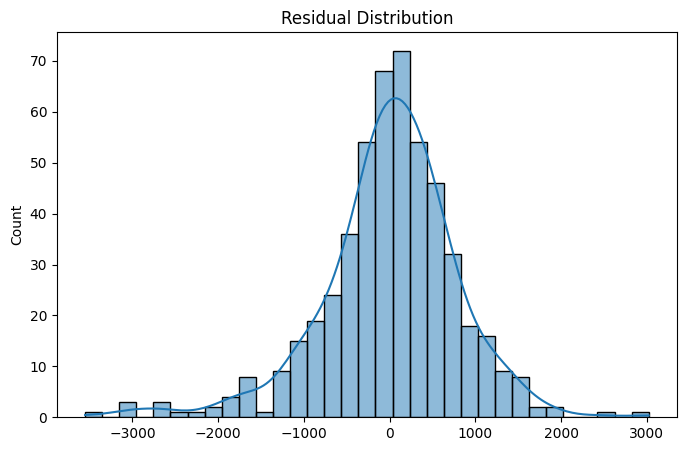

In [106]:
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.show()

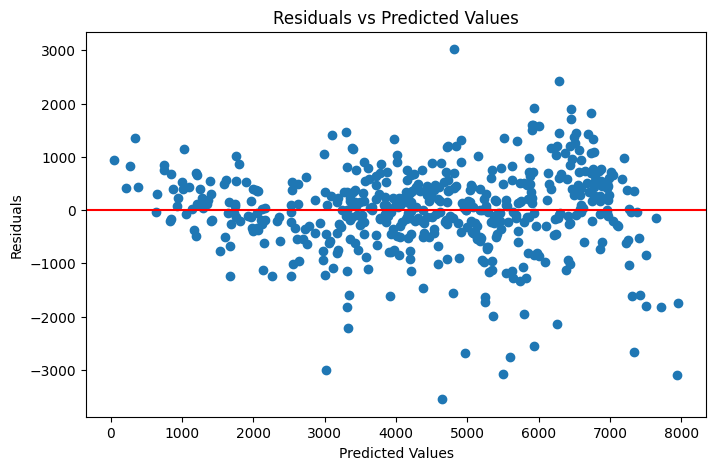

In [107]:
plt.figure(figsize=(8,5))
plt.scatter(y_train_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

### Residual Analysis Findings

Residual diagnostics were performed to validate the assumptions of the Multiple Linear Regression model.

The residual distribution was approximately **normal and centered around zero**, indicating that the model errors do not exhibit substantial bias.

The Residuals vs Predicted Values plot showed a largely random distribution of residuals around the zero line, supporting the **linearity assumption of the regression model**.

Although a slight increase in variance was observed at higher predicted values, the **heteroscedasticity** was not severe enough to significantly affect model validity.

Overall, the residual analysis indicates that the **final regression model satisfies the key assumptions required for reliable prediction and interpretation**.

In [108]:
X_test_final = X_test.drop(['mnth','atemp'], axis=1)

X_test_final = sm.add_constant(X_test_final)

y_pred = lr3_model.predict(X_test_final)

In [109]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("RMSE:", rmse)

R2 Score: 0.8096391848904636
RMSE: 829.2534814748549


### Final Model Performance on Test Data

The refined Multiple Linear Regression model was evaluated on the unseen test dataset to assess its generalization capability.

**Performance Metrics**

- R-squared (Test): **0.810**
- RMSE: **829.25**

The test R-squared value indicates that approximately **81% of the variation in bike rental demand** is explained by the model on unseen data.

The relatively close alignment between training Adjusted R-squared (0.829) and testing R-squared (0.810) suggests that the model generalizes well and does not suffer from significant overfitting.

The RMSE value of 829.25 indicates the average prediction error in rental counts and is acceptable considering the scale of bike demand observations.

Overall, the final model demonstrates strong predictive performance and reliable generalization ability.

### Key Business Insights

The regression analysis identified several factors that significantly influence bike rental demand:

1. **Temperature (temp)** showed a strong positive relationship with bike demand, indicating that warmer weather encourages more bike rentals.

2. **Humidity (hum)** negatively impacted demand, suggesting that riders prefer less humid conditions.

3. **Windspeed** exhibited a significant negative effect on rentals, indicating reduced usage during windy conditions.

4. **Weather conditions** such as light rain and mist significantly reduced bike demand compared to clear weather.

5. **Seasonal effects** were evident, with summer and winter showing higher demand relative to the baseline season, while spring showed relatively lower demand.

6. **Working days and weekdays** positively influenced rental counts, indicating higher usage during routine commuting periods.

7. **Year (yr)** had a strong positive coefficient, reflecting the overall growth in bike-sharing adoption over time.

# Conclusion

A **Multiple Linear Regression model** was developed to identify the key drivers of bike-sharing demand.

The modeling process included:

- Data cleaning and preparation
- Exploratory Data Analysis
- Dummy variable creation
- Train-test split
- Feature scaling
- Iterative feature elimination using p-values
- Multicollinearity assessment using VIF
- Residual diagnostics
- Final model evaluation

Variables with high p-values (atemp and mnth) were removed to create a more parsimonious model without sacrificing predictive performance.

The final model achieved:

- Adjusted R-squared = **0.829**
- Test R-squared = **0.810**
- RMSE = **829.25**

**Residual and VIF analyses** confirmed that the key assumptions of Multiple Linear Regression were reasonably satisfied.

Therefore, the final model is statistically sound, interpretable, and capable of explaining a substantial proportion of variation in bike rental demand.

The findings can support business decisions related to operational planning, demand forecasting, resource allocation, and seasonal strategy optimization.